# Load ERA5-Land Data

In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import sys
WORK_DIR = "/home/research/jenzheng/documents/kai/research/eta/eta"
sys.path.append(WORK_DIR)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from plot_utils import plot_setting, plot_nfields
from utils import *
import torch
import torch.nn as nn
from tqdm import tqdm
from kde import get_data_pdf
plot_setting()

# Load the cropped data
file_path = WORK_DIR + '/data/ERA5/era5land_USA_SouthEast_1999-2023_dailymax.nc'
ds = xr.open_dataset(file_path, engine='netcdf4')

# Extract the 'tp' variable (Total Precipitation)
tp = ds['tp']

# Convert to a NumPy array and multiply by 1000 (meter to millimeter)
tp_numpy = tp.values * 1000
# 
# Check if there are any NaN values
has_nan = np.isnan(tp_numpy).any()
# print(f"Contains NaN values: {has_nan}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<xarray.DataArray 'tp' (time: 9050, latitude: 80, longitude: 160)> Size: 463MB
[115840000 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 72kB 1999-01-01T11:30:00 ... 2023-12-31...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 640B 38.7 38.6 38.5 38.4 ... 31.0 30.9 30.8
  * longitude   (longitude) float64 1kB -97.6 -97.5 -97.4 ... -81.9 -81.8 -81.7
    valid_time  (time) datetime64[ns] 72kB ...
Attributes: (12/29)
    GRIB_paramId:                             228
    GRIB_numberOfPoints:                      150851
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_name:                                Total precipitation
    GRIB_shortName:                           tp
    GRIB_uni

# Data Preprocessing


In [ ]:
# Downsampling by a factor of 2 for each spatial dimension
ds_fact = 10
tp_ds_numpy = tp_numpy[:, ::ds_fact, ::ds_fact]  # (9050, 40, 80)

max_values_original = np.max(tp_numpy, axis=(1, 2))

# max_values_original will have shape (9050,)
print(max_values_original.shape)

# Sort max_values and get the indices that would sort the array
sorted_indices_original = np.argsort(max_values_original)
print(0 in sorted_indices_original)

# Use the sorted_indices to get the sorted max_values
sorted_max_values_original = max_values_original[sorted_indices_original]

# trim the tail
trim_tail_thresh = 240
num_trim_days = len(sorted_max_values_original[sorted_max_values_original > trim_tail_thresh])
trim_days = sorted_indices_original[-num_trim_days:]
sorted_max_values_trim = sorted_max_values_original[:-num_trim_days]
sorted_indices_trim = sorted_indices_original[:-num_trim_days]
print("Trimmed Days: ", trim_days)
print("Trimmed Values: ", sorted_max_values_original[-num_trim_days:])

kept_days = np.delete(np.arange(len(tp_numpy)), trim_days)
tp_trim_numpy = tp_numpy[kept_days]
tp_trim_ds_numpy = tp_ds_numpy[kept_days]
tp_trim_tensor = torch.tensor(tp_trim_numpy)
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy)
print(tp_trim_ds_tensor.shape)
print(tp_trim_tensor.shape)

# Select $\eta$ Training Data

In [7]:
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import os
import gc

# Convert numpy arrays to PyTorch tensors and move to GPU
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
tp_trim_tensor = torch.tensor(tp_trim_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Full-resolution target

# Use 20% of the data (5 years) for training
num_years = 0.5
portion = num_years/25
train_size = int(portion * len(tp_trim_ds_tensor))
train_input = tp_trim_ds_tensor[:train_size]
train_target = tp_trim_tensor[:train_size]

# use full data to select the best MSE model for baseline comparison
test_input = deepcopy(tp_trim_ds_tensor)
test_target = deepcopy(tp_trim_tensor)

# move data to device
train_input = train_input.to(device)
train_target = train_target.to(device)
test_input = test_input.to(device)
test_target = test_target.to(device)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])
torch.Size([9044, 1, 8, 16])
torch.Size([9044, 1, 80, 160])


# $\eta$ Testing Function

In [8]:
def test_model_eta(model, TestLoader, 
                   w1_loss, w1_input, w1_truemax, w1_max_pos, 
                   device=None):
    """
    run model on TestLoader and report the MSE loss and the W1 loss
    
    return:
        - full_output: squeezed numpy array with dimension (N,...)
        - test_loss_mse: mean squared error on TestLoader
    
    """
    if not device:
        device = next(model.parameters()).device
    model.to(device)
    model.eval()
    _, sample_target = next(iter(TestLoader))
    full_output = torch.zeros_like(sample_target[0]).cpu()
    mse_loss = nn.MSELoss()
    running_test_mse_loss = 0.0
    
    with torch.no_grad():
        for _, (test_in, test_tar) in enumerate(test_loader):
            test_in, test_tar = test_in.to(device), test_tar.to(device)  
            test_output = model(test_in).detach()
            loss = mse_loss(test_output, test_tar)
            running_test_mse_loss += loss.item()
            full_output = torch.cat((full_output,test_output.squeeze().cpu()),dim=0)
    test_mse_loss = running_test_mse_loss/len(test_loader)
    
    # when testing, should record the true tail values
    num_w1_days = len(w1_truemax)
    full_output = full_output[1:].numpy()
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    w1_max_test = torch.tensor(sorted_max_values_output[-num_w1_days:])
    w1_max_test = w1_max_test.to(w1_truemax.device)
    
#     w1_output_test = model(w1_input).squeeze()
#     w1_max_test = w1_output_test[tuple(w1_max_pos)]
    w1_loss_test = w1_loss(w1_max_test, w1_truemax).item()
    
    return full_output, test_mse_loss, w1_loss_test

def get_max_indices_vals(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_indices = sorted_indices_output[-num_w1_days:]
    max_vals = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_indices, max_vals

# Load DGM Samples

In [9]:
load_path_lores_samples = WORK_DIR + f"/samples/9044samples-lores-fm-100step-unet16-25yr-80epoch.npy"
load_path_hires_samples_0p5 = WORK_DIR + f"/samples/9044samples-hires-fm-200step-unet16-0.5yr-200epoch.npy"
load_path_hires_samples_2p5 = WORK_DIR + f"/samples/9044samples-hires-fm-200step-unet16-2.5yr-100epoch.npy"
load_path_hires_samples_10 = WORK_DIR + f"/samples/9044samples-hires-fm-200step-unet16-10yr-100epoch.npy"
# load_path_hires_samples_17p5 = WORK_DIR + f"/samples/9044samples-hires-fm-100step-unet16-17.5yr-50epoch.npy"
load_path_hires_samples_25 = WORK_DIR + f"/samples/9044samples-hires-fm-200step-unet16-25yr-50epoch.npy"

lores_samples = np.load(load_path_lores_samples)
hires_samples_0p5 = np.load(load_path_hires_samples_0p5)
hires_samples_2p5 = np.load(load_path_hires_samples_2p5)
hires_samples_10 = np.load(load_path_hires_samples_10)
# hires_samples_17p5 = np.load(load_path_hires_samples_17p5)
hires_samples_25 = np.load(load_path_hires_samples_25)

# Load $\eta$-Map

In [10]:
from models import SRCNN
num_years = 0.5
ds_fact = 10
w1_tail_thresh = 150
omega = 30
load_dir = WORK_DIR + "/models/precip-srcnn/"
model_eta_filename = f"srcnn-eta-{num_years}yr-{ds_fact}ds-{w1_tail_thresh}tail-{omega}omega.pth"
model_eta = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
load_path_eta = os.path.join(load_dir, model_eta_filename)
model_eta = nn.DataParallel(model_eta)#, device_ids=[3])
model_eta.load_state_dict(torch.load(load_path_eta))
model_eta.to(device)
print()

# Run $\eta$ on DGM Low-Res Samples

In [11]:
test_dataset = TensorDataset(torch.tensor(lores_samples).unsqueeze(1), torch.tensor(hires_samples_0p5).unsqueeze(1))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

w1_loss = lambda x,y: torch.abs(x-y).mean()
w1_truemax = torch.tensor([1.])
full_output_eta, _, _ = test_model_eta(
    model_eta,
    test_loader,
    w1_loss,
    None,
    w1_truemax,
    None,
    device=device
)


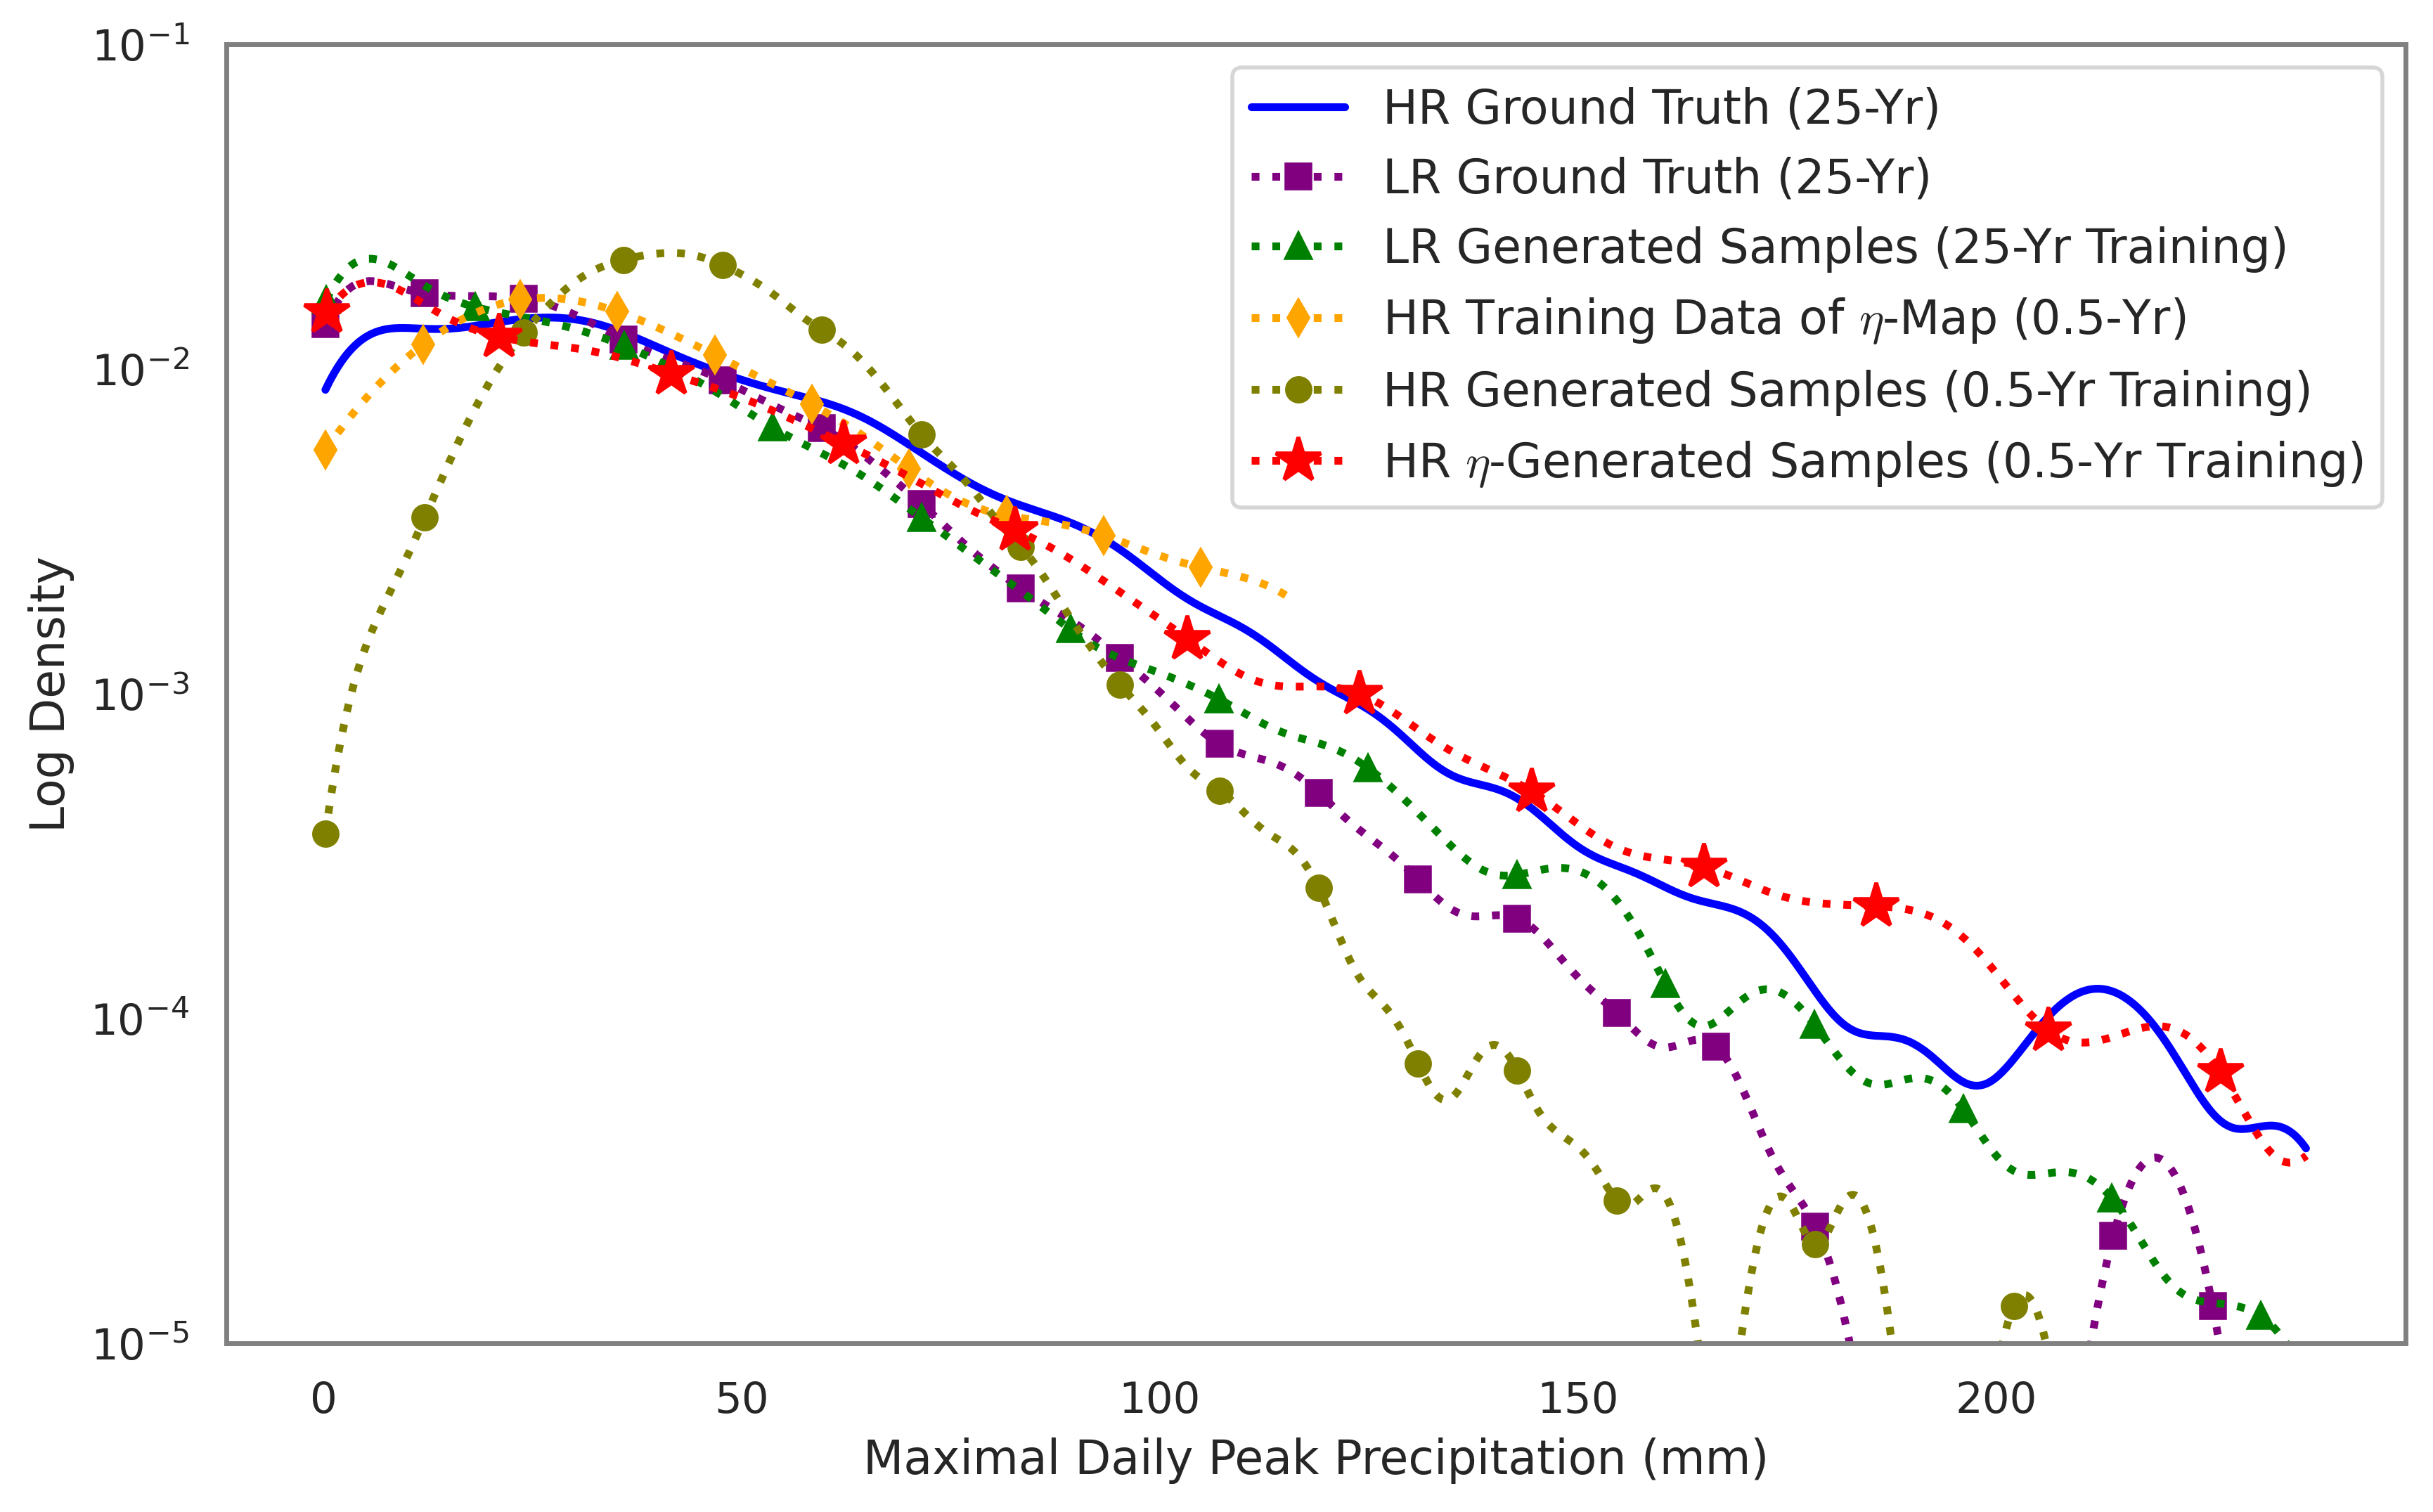

In [12]:
# diagonose ddpm sample stats
hires_sample_max_values_0p5 = np.max(hires_samples_0p5, axis=(1,2))
max_values_eta_lores = np.max(full_output_eta, axis=(1,2))
max_values_ds = np.max(tp_trim_ds_numpy, axis=(1,2))
max_values_lores = np.max(lores_samples, axis=(1,2))
max_values = np.max(tp_trim_numpy, axis=(1,2))
max_values_train = np.max(tp_trim_numpy[:train_size], axis=(1,2))
# hires_sample_max_values_0p5 = hires_sample_max_values_0p5[hires_sample_max_values_0p5 < train_max_values.max()]

y_eval_tp, py_tp, _ = get_data_pdf(data=torch.tensor(max_values), data_all=torch.tensor(max_values))
y_eval_tp_train, py_tp_train, _ = get_data_pdf(data=torch.tensor(max_values_train), data_all=torch.tensor(max_values_train))
y_eval_tp_hires_sample_0p5, py_tp_hires_sample_0p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_0p5), data_all=torch.tensor(max_values))
y_eval_tp_ds, py_tp_ds, _ = get_data_pdf(data=torch.tensor(max_values_ds), data_all=torch.tensor(max_values))
y_eval_tp_lores_sample, py_tp_lores_sample, _ = get_data_pdf(data=torch.tensor(max_values_lores), data_all=torch.tensor(max_values))
y_eval_tp_eta_lores_sample, py_tp_eta_lores_sample, _ = get_data_pdf(data=torch.tensor(max_values_eta_lores), data_all=torch.tensor(max_values))
# Plotting KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Create marker indices (about 10 markers per line)
marker_every = 50

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label=r"HR Ground Truth (25-Yr)", color='blue', linestyle='-', linewidth=2) 
        #  marker='o', markevery=marker_every)
plt.plot(y_eval_tp_ds, py_tp_ds, label=r"LR Ground Truth (25-Yr)", color='purple', linestyle=':', 
         marker='s', markevery=marker_every, linewidth=2)
plt.plot(y_eval_tp_lores_sample, py_tp_lores_sample, label=r"LR Generated Samples (25-Yr Training)", color='green', linestyle=':', 
         marker='^', markevery=marker_every, linewidth=2)
plt.plot(y_eval_tp_train, py_tp_train, label=r"HR Training Data of $\eta$-Map (0.5-Yr)", color='orange', linestyle=':', 
         marker='d', markevery=100, linewidth=2)
plt.plot(y_eval_tp_hires_sample_0p5, py_tp_hires_sample_0p5, label=r"HR Generated Samples (0.5-Yr Training)", color='olive', linestyle=':', 
         marker='o', markevery=marker_every, linewidth=2)
plt.plot(y_eval_tp_eta_lores_sample, py_tp_eta_lores_sample, label=r"HR $\eta$-Generated Samples (0.5-Yr Training)", color='red', linestyle=':', 
         marker='*', markersize=12, markevery=marker_every, linewidth=2)

# Add plot labels and title
plt.xlabel("Maximal Daily Peak Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.ylim(1e-5,1e-1)
plt.legend(prop={"size" : 12})

In [13]:
hires_sample_max_values_0p5 = np.max(hires_samples_0p5, axis=(1,2))
hires_sample_max_values_2p5 = np.max(hires_samples_2p5, axis=(1,2))
hires_sample_max_values_10 = np.max(hires_samples_10, axis=(1,2))
# hires_sample_max_values_17p5 = np.max(hires_samples_17p5, axis=(1,2))
hires_sample_max_values_25 = np.max(hires_samples_25, axis=(1,2))

y_eval_tp_hires_sample_0p5, py_tp_hires_sample_0p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_0p5), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_2p5, py_tp_hires_sample_2p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_2p5), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_10, py_tp_hires_sample_10, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_10), data_all=torch.tensor(max_values))
# y_eval_tp_hires_sample_17p5, py_tp_hires_sample_17p5, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_17p5), data_all=torch.tensor(max_values))
y_eval_tp_hires_sample_25, py_tp_hires_sample_25, _ = get_data_pdf(data=torch.tensor(hires_sample_max_values_25), data_all=torch.tensor(max_values))

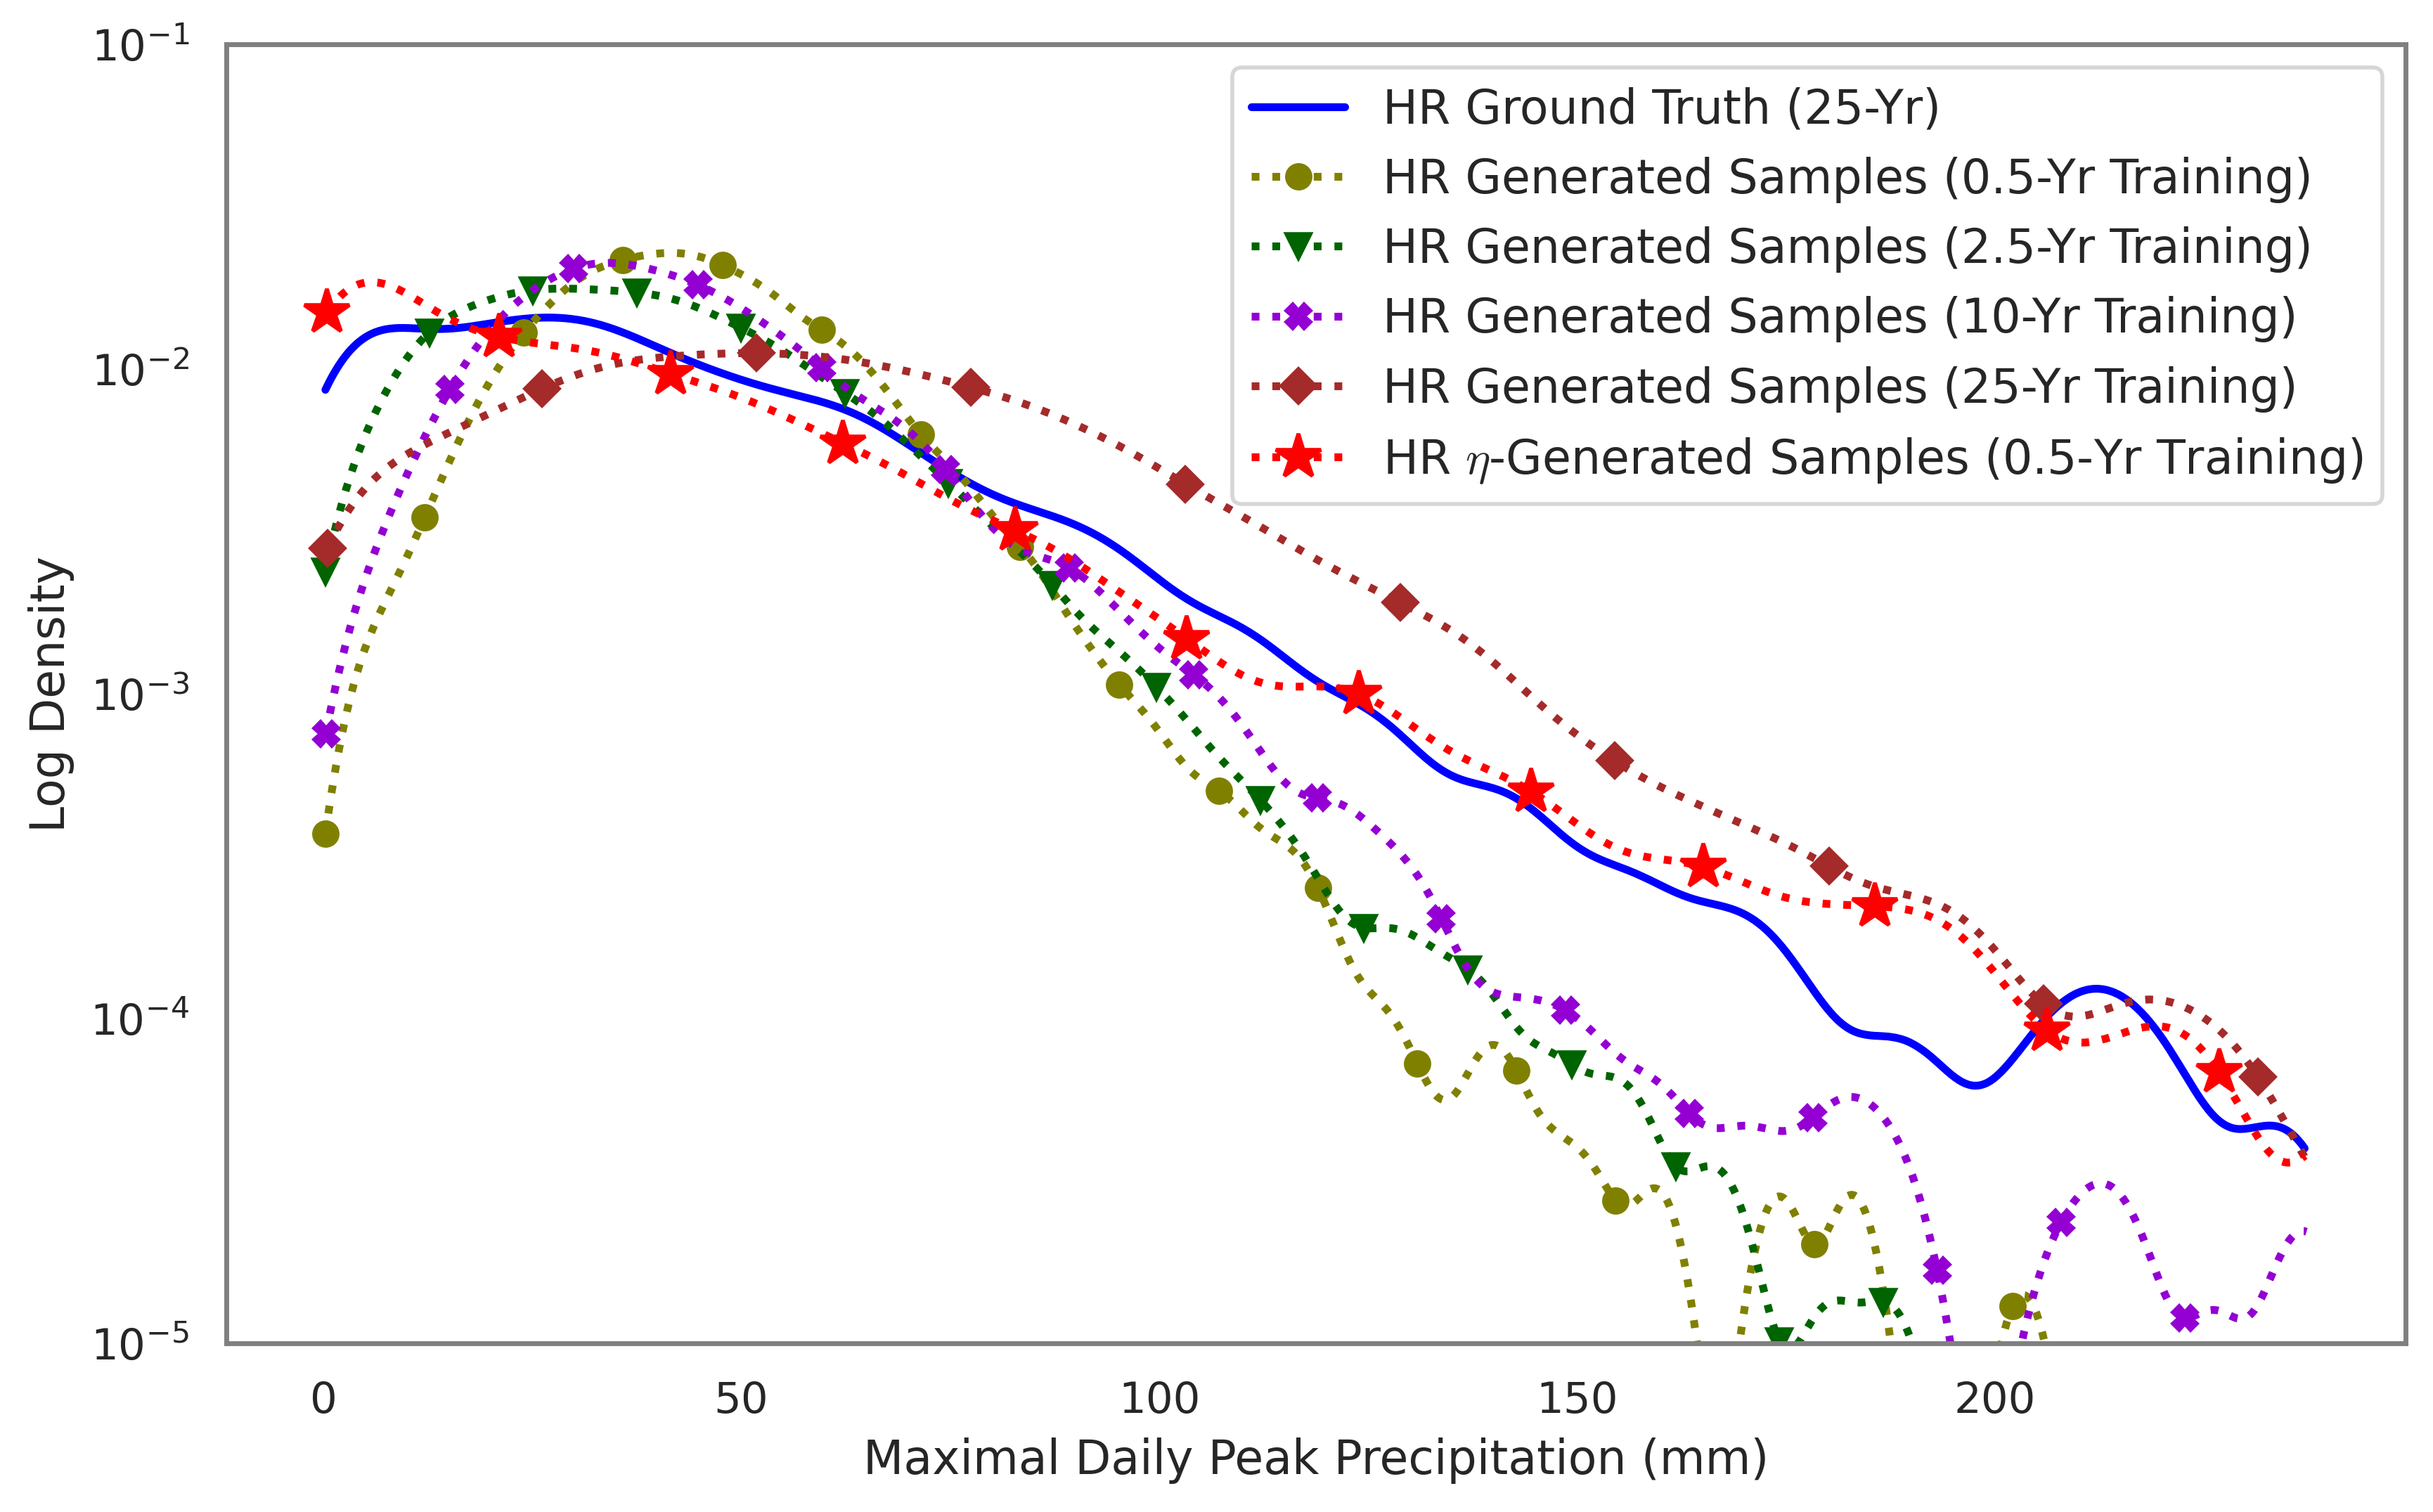

In [14]:
# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Create marker indices (about 10 markers per line)
marker_every = 50

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label=r"HR Ground Truth (25-Yr)", color='blue', linestyle='-', linewidth=2)
plt.plot(y_eval_tp_hires_sample_0p5, py_tp_hires_sample_0p5, label=r"HR Generated Samples (0.5-Yr Training)", color='olive', linestyle=':', 
         marker='o', markevery=marker_every, linewidth=2)
plt.plot(y_eval_tp_hires_sample_2p5, py_tp_hires_sample_2p5, label=r"HR Generated Samples (2.5-Yr Training)", color='darkgreen', linestyle=':', 
         marker='v', markevery=marker_every, linewidth=2)
plt.plot(y_eval_tp_hires_sample_10, py_tp_hires_sample_10, label=r"HR Generated Samples (10-Yr Training)", color='darkviolet', linestyle=':', 
         marker='X', markevery=marker_every, linewidth=2)
# plt.plot(y_eval_tp_hires_sample_17p5, py_tp_hires_sample_17p5, label=r"HR Generated Samples (17.5-Yr Training)", linestyle='--')
plt.plot(y_eval_tp_hires_sample_25, py_tp_hires_sample_25, label=r"HR Generated Samples (25-Yr Training)", color='brown', linestyle=':', 
         marker='D', markevery=marker_every, linewidth=2)
plt.plot(y_eval_tp_eta_lores_sample, py_tp_eta_lores_sample, label=r"HR $\eta$-Generated Samples (0.5-Yr Training)", color='red', linestyle=':', 
         marker='*', markersize=12, markevery=marker_every, linewidth=2)


# Add plot labels and title
plt.xlabel("Maximal Daily Peak Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.ylim(1e-5,1e-1)
plt.legend(prop={"size" : 12})

In [15]:
def get_max_indices_values(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_value_indices = sorted_indices_output[-num_w1_days:]
    max_values = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_value_indices, max_values

ndays = 100
max_value_indices_plot, max_values_plot = get_max_indices_values(full_output_eta, ndays)
ntrunc = len(max_values_plot[max_values_plot > 240])
print(max_value_indices_plot[:ndays - ntrunc])
print(ntrunc)

[2455  278 3101 8351 5740 1757 3218 6825 3303 2817 6522 2303  453 6806
 6747 6717 4347 3702 2098 3454 7223 4126 1641 5874 2321  347 7793 3412
 3735 2851 1069   73 6032 6829 4017  940 6008   51 8653 4900 4479 3516
 2242 6568 8740 7646 4794 5820 3933 3939 3789 2173  104  375 7289 7400
 4001 2900 6542 2021  529 6752 1643 6388 4072 8892 4389  271  653 1933
 3729 1837 6231 5783 8145 4931   70 1229]
22


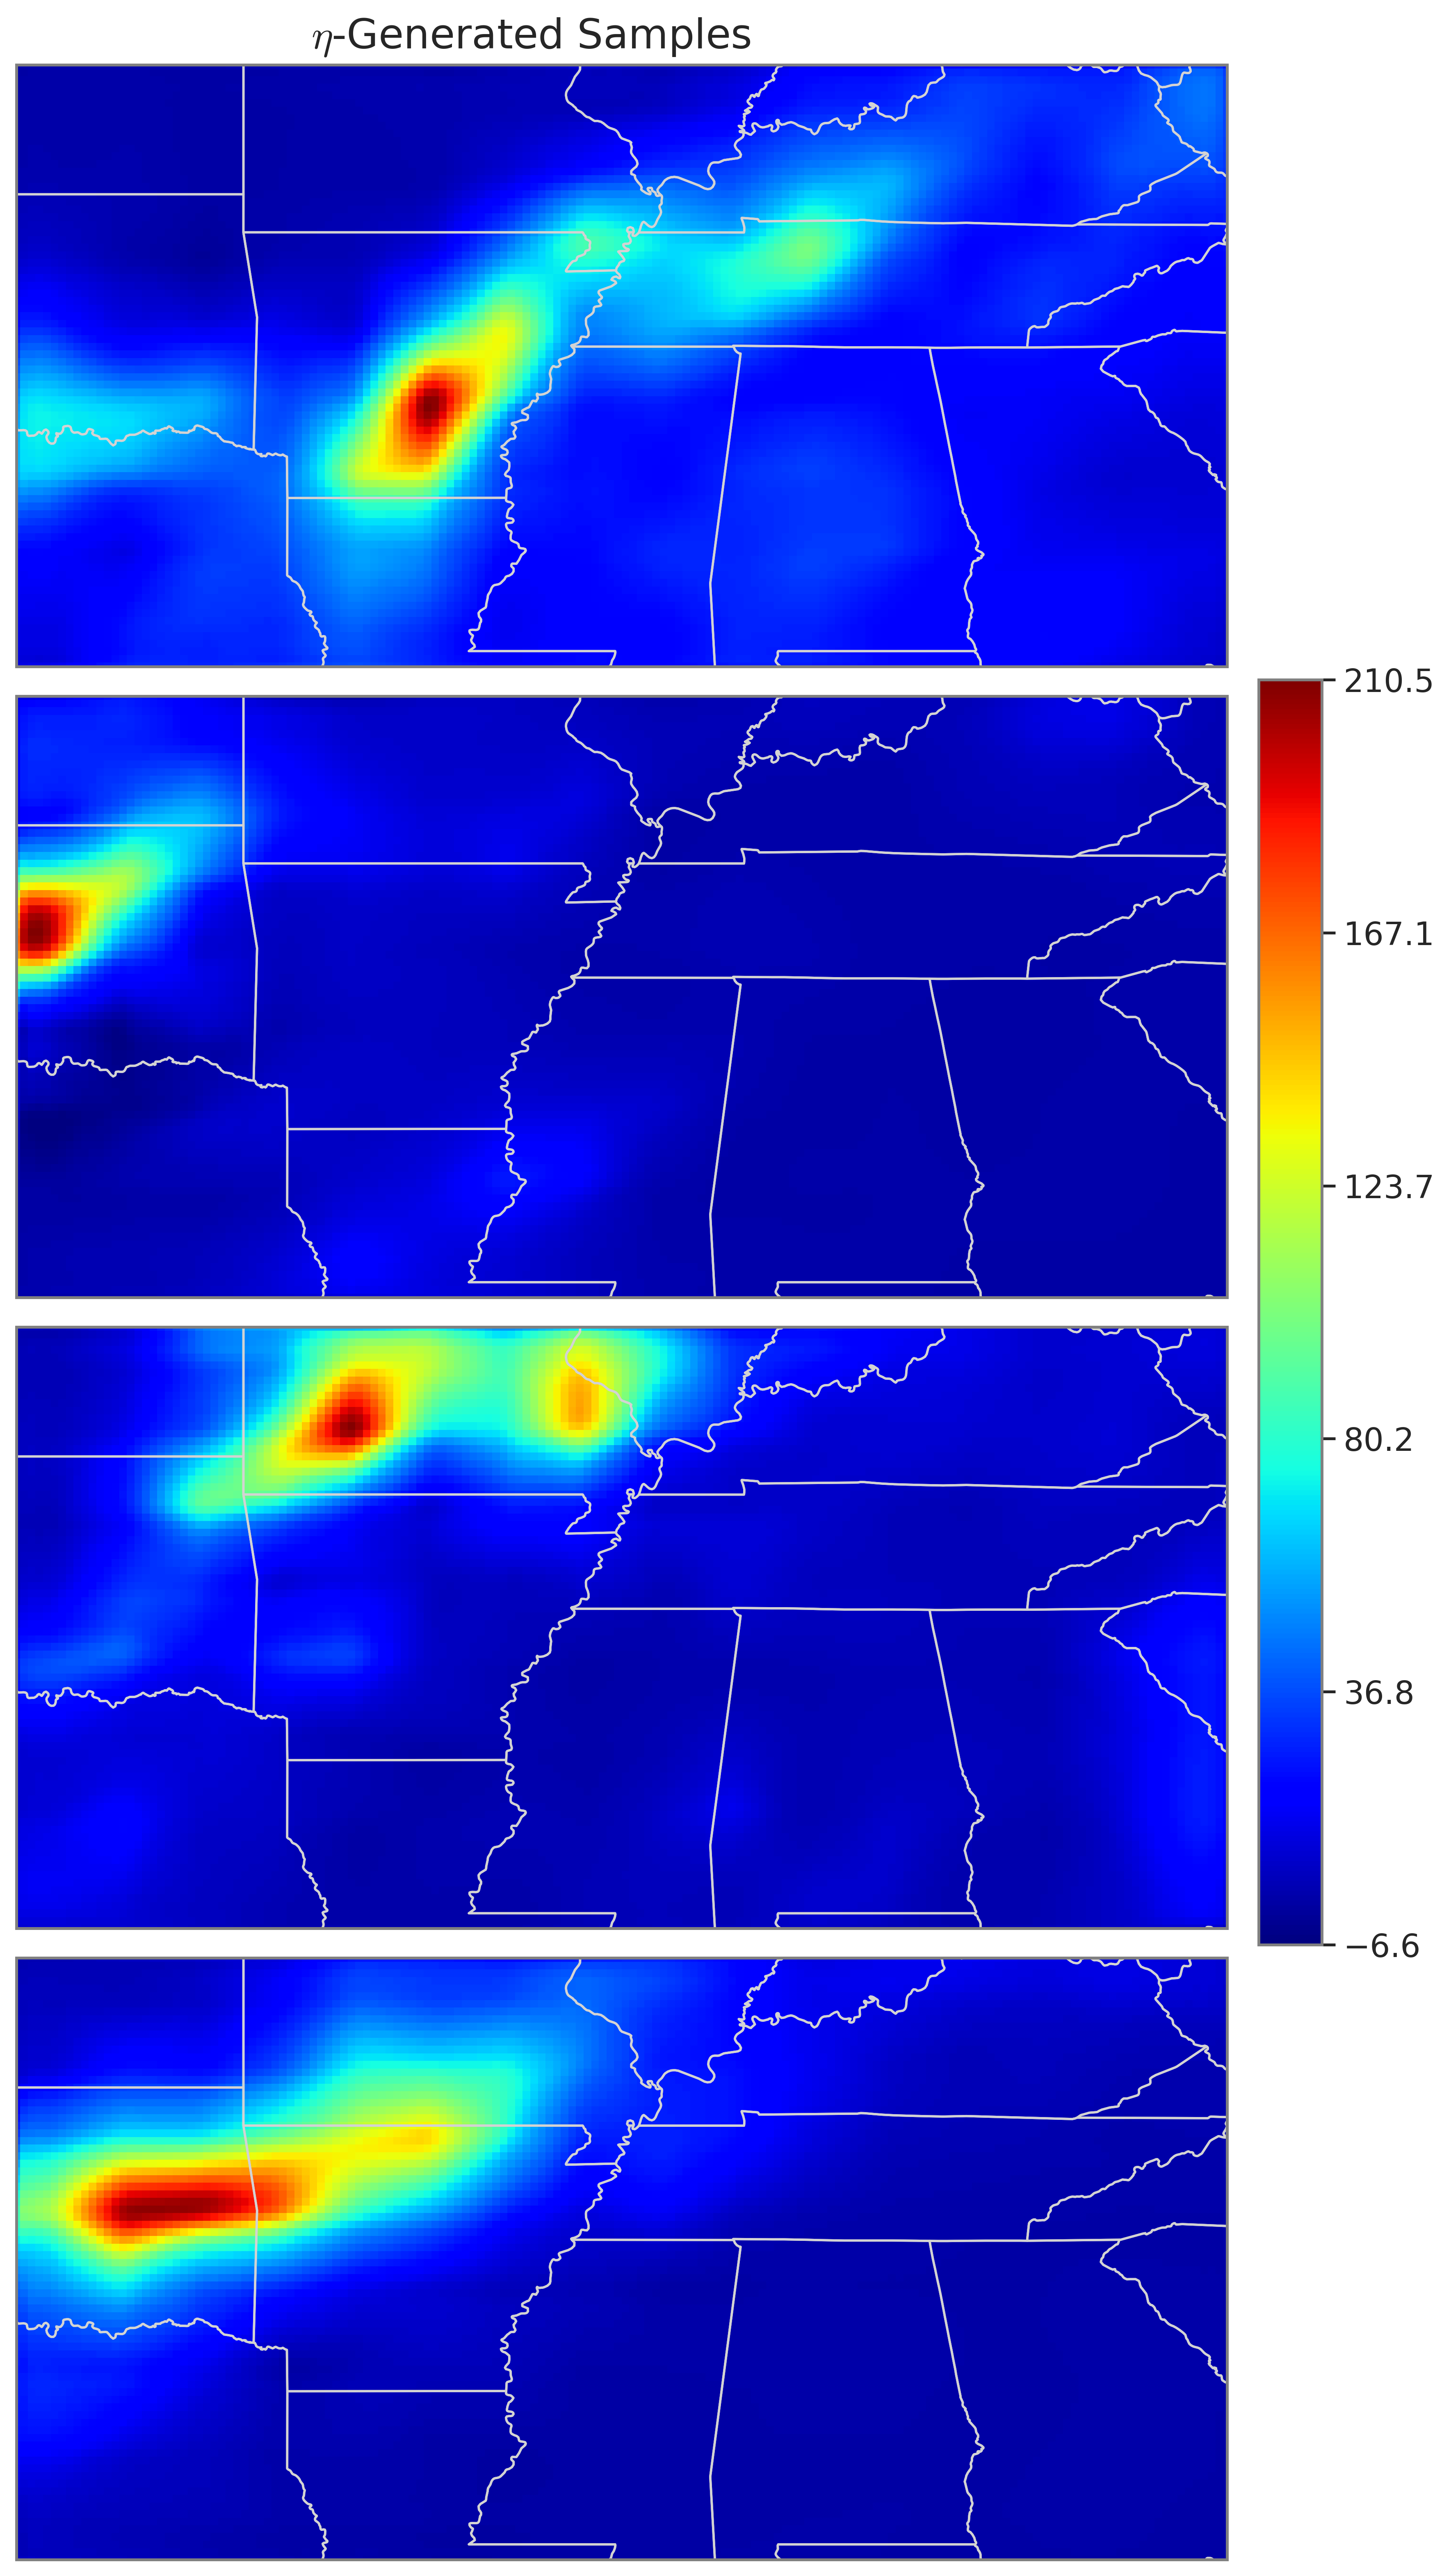

In [23]:
pic_idx = 4
fig,axes = plot_nfields(full_output_eta[max_value_indices_plot[-4*pic_idx-1-ntrunc]],
                        full_output_eta[max_value_indices_plot[-4*pic_idx-2-ntrunc]],
                        full_output_eta[max_value_indices_plot[-4*pic_idx-3-ntrunc]], 
                        full_output_eta[max_value_indices_plot[-4*pic_idx-4-ntrunc]],
                        longitudes = tp.longitude.values,
                        latitudes = tp.latitude.values,
                        title = r"$\eta$-Generated Samples")